In [2]:
import pandas as pd
import numpy as np 
from keras.models import Sequential
from keras import layers, ops 
import keras
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [3]:
X = np.load("../Data/X_train.npy")
Y = np.load("../Data/Y_train.npy")

print(X.shape)
print(Y.shape)

(20631, 14)
(20631,)


In [4]:
def AutoEncoder(X, input_dim, latent_dim, output_dim):
    model = Sequential([
        # Encoding phase
        keras.Input((input_dim, )),
        layers.Dense(16, name = 'Enc_layer1', kernel_initializer= 'he_normal'),
        layers.LeakyReLU(alpha = 0.01),
        layers.Dense(8, name = 'Enc_layer2', kernel_initializer= 'he_normal'),
        layers.LeakyReLU(alpha = 0.01),
        layers.Dense(latent_dim, name = 'Latent_Space', kernel_initializer= 'he_normal'), 
        layers.LeakyReLU(alpha = 0.01), 

        #Decoding phase
        layers.Dense(8, name = "dec_dense1", kernel_initializer= 'he_normal'),
        layers.LeakyReLU(alpha = 0.01),
        layers.Dense(16, name = "dec_dense2", kernel_initializer= 'he_normal'),
        layers.LeakyReLU(alpha = 0.01),
        layers.Dense(output_dim, name="output_layer", kernel_initializer= 'he_normal')
    ])
    # model.summary()
    return model

In [5]:
def train(X, epochs, batch_size): 
    input_dim = X.shape[1]
    latent_dim = 4
    output_dim = X.shape[1]
    model = AutoEncoder(X, input_dim, latent_dim, output_dim)

    model.compile(optimizer = keras.optimizers.Adam(learning_rate = 0.0005), loss = 'mse')

    early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
    model.fit(X, 
              X,
              epochs = epochs,
              batch_size = batch_size,
              verbose = 1,
              shuffle = True,
              callbacks = [early_stop]
             )

    X_decoded = model.predict(X)

    return X_decoded, model
    

In [9]:
X_decoded, model = train(X, epochs=100, batch_size=256)

Epoch 1/100


/Users/shivaram/telemetry-anomaly-detector/.venv/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 442us/step - loss: 0.1886 
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 337us/step - loss: 0.1077
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step - loss: 0.0486
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step - loss: 0.0256
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - loss: 0.0195
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step - loss: 0.0182
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step - loss: 0.0179
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 326us/step - loss: 0.0178
Epoch 9/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 335us/step - loss: 0.0177
Epoch 10/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step - loss: 0.0175
Epoch 11/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step - loss: 0.0173
Epoch 12/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step - loss: 0.0171
Epoch 13/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step - loss: 0.0166
Epoch 14/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - loss: 0.0158
Epoch 15/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step 

645/645 ━━━━━━━━━━━━━━━━━━━━ 0s 167us/step


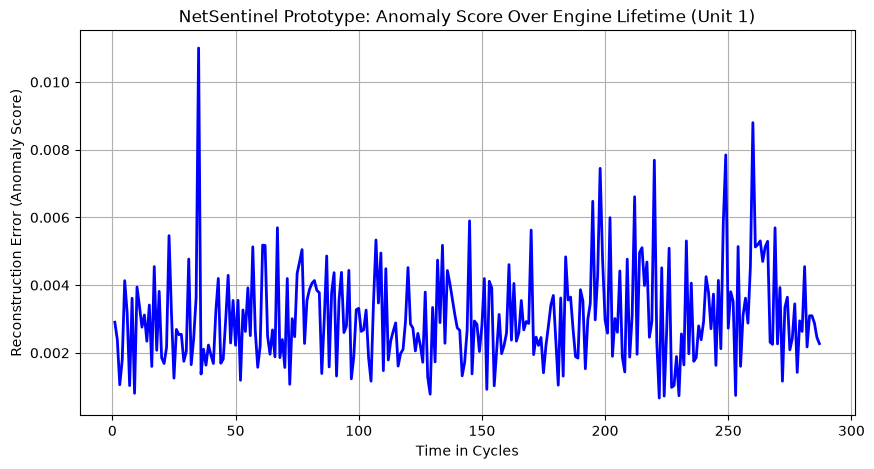

In [7]:
X_pred = model.predict(X)
reconstruction_errors = np.mean(np.square(X - X_pred), axis=1)

metadata = pd.read_csv('../Data/metadata.csv')

metadata['anomaly_score'] = reconstruction_errors

engine_1 = metadata[metadata['unit_number'] == 2].sort_values('time_in_cycles')

plt.figure(figsize=(10, 5))
plt.plot(engine_1['time_in_cycles'], engine_1['anomaly_score'], color='blue', linewidth=2)
plt.title("NetSentinel Prototype: Anomaly Score Over Engine Lifetime (Unit 1)")
plt.xlabel("Time in Cycles")
plt.ylabel("Reconstruction Error (Anomaly Score)")
plt.grid(True)
plt.show()

In [8]:
model.save("../Model/AutoEncoder.keras")
print("Model saved sucessfully!")

Model saved sucessfully!
